In [1]:
import sys
import pathlib      
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
project_root = pathlib.Path.cwd().parent      # .. (= folder that contains toolbox/)
if project_root.as_posix() not in sys.path:   # avoid duplicates
    sys.path.insert(0, project_root.as_posix())
import toolbox.pipeline as tp
importlib.reload(tp)

import numpy as np
import matplotlib.pyplot as plt

# Deine Module importieren
from toolbox.pipeline.gabor import run, compute_pc
from toolbox.pipeline.postprocessing import get_nms_map, visualize_nms_process


In [2]:
# only used as an overlay
img = cv2.imread("gebiet_4_enhanced_contrast.tif")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
rgb
#plt.imshow(rgb)


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[247, 178,  38],
        [244, 159,  36],
        [237, 129,  33],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[243, 144,  34],
        [237, 129,  33],
        [233, 115,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[239, 137,  34],
        [235, 122,  32],
        [230, 108,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [3]:
results = run("gebiet_4_enhanced_contrast.tif", tile_size=512, return_kernels=True, return_eo=True)


pc_max, pc_t, best_theta_idx = compute_pc(
    results["AMP"], 
    results["PHI"], 
    k=4.0 # Noise threshold
)


Auto kernel size for sigma_max=24: (145, 145)


In [4]:
thetas_u = results["theta_deg"]

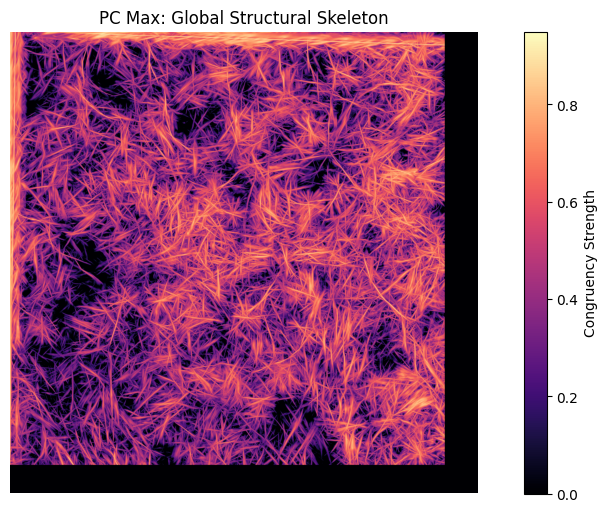

In [5]:
# 1. PC_max (Das aggregierte Ergebnis über alle Richtungen)
plt.figure(figsize=(12, 6))
plt.imshow(pc_max, cmap='magma')
plt.title("PC Max: Global Structural Skeleton")
plt.colorbar(label='Congruency Strength')
plt.axis('off')
plt.show()


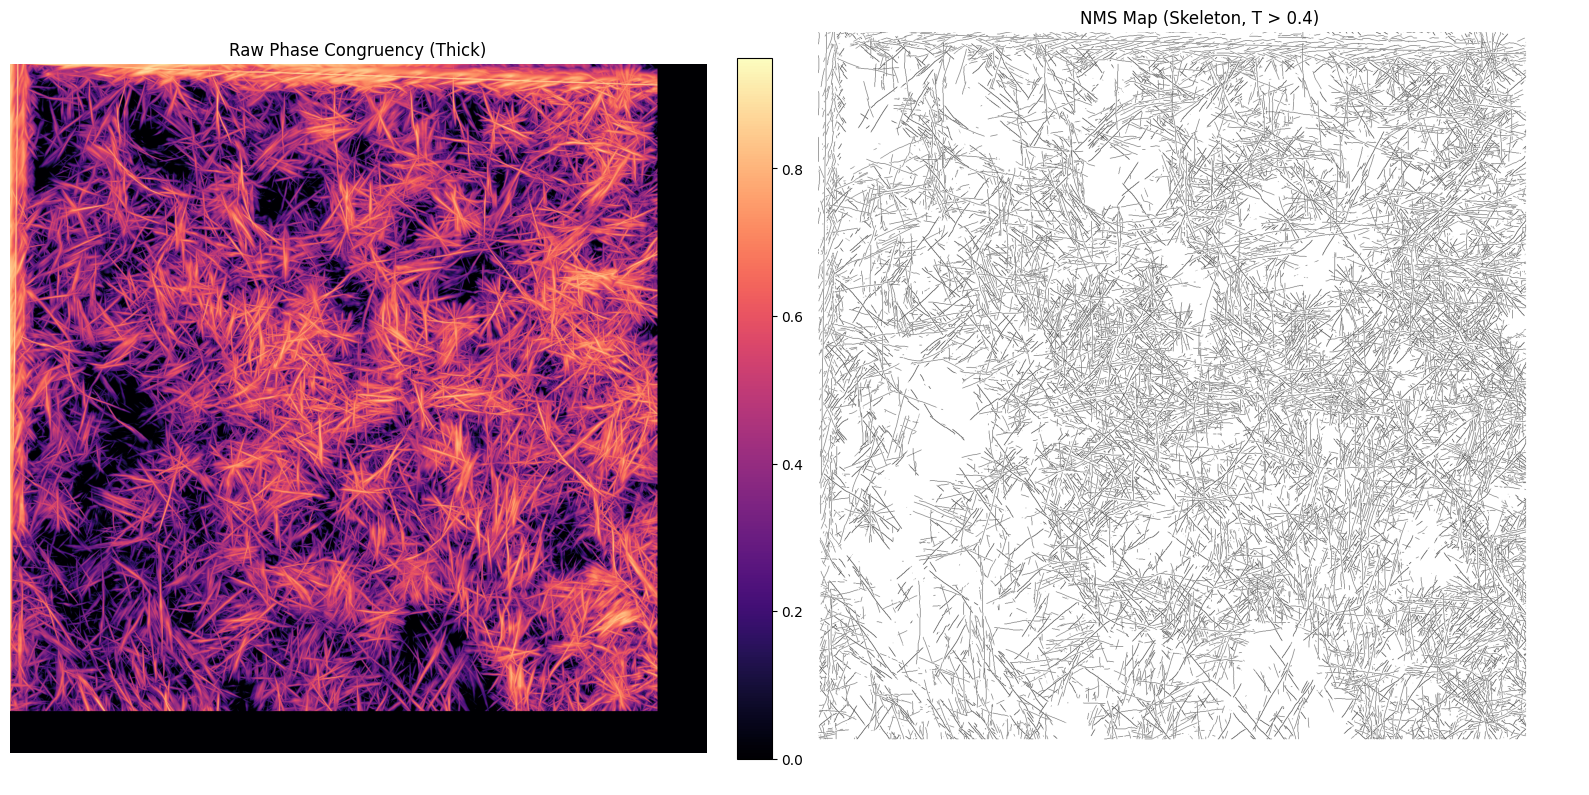

In [6]:
nms_map = get_nms_map(pc_max, best_theta_idx, np.deg2rad(thetas_u))

# 4. Visualisierung des PoC
visualize_nms_process(pc_max, nms_map, threshold=0.4)

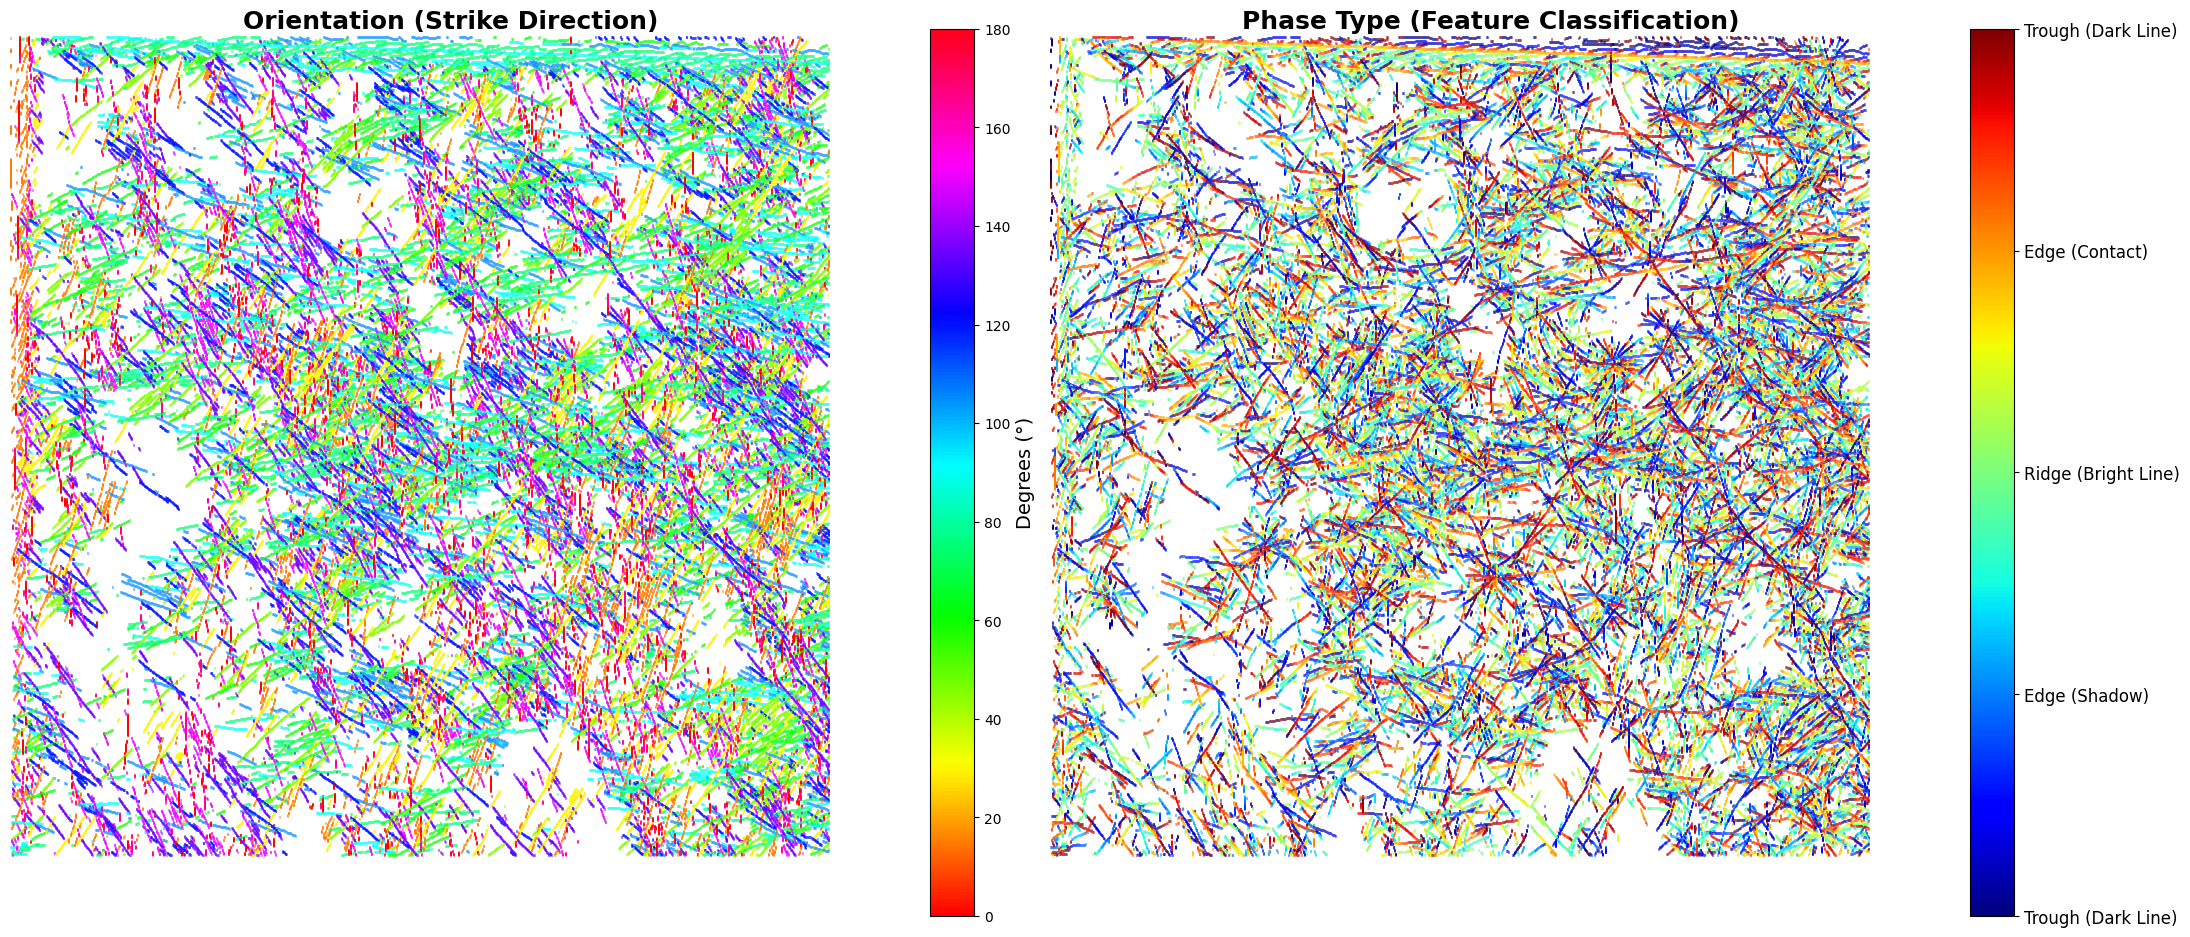

array([[-3.1305876, -3.1144555, -3.0792887, ...,  0.       ,  0.       ,
         0.       ],
       [-3.1182284, -3.1041157, -3.0719614, ...,  0.       ,  0.       ,
         0.       ],
       [-3.1066453, -3.0957956, -3.0674415, ...,  0.       ,  0.       ,
         0.       ],
       ...,
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ]], shape=(2104, 2127), dtype=float32)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

def visualize_geology_vibrant_axis(PC_t, PHI, nms_map, linewidth=2.0):
    # 1. Setup Data & Coordinates
    num_orient = PC_t.shape[0]
    thetas = np.linspace(0, np.pi, num_orient, endpoint=False)
    best_idx = np.argmax(PC_t, axis=0)
    
    # Use Scale 1 for the most distinct phase classification
    if PHI.ndim == 4:
        phi_working = PHI[1]
    else:
        phi_working = PHI
    best_phi = np.take_along_axis(phi_working, best_idx[None, ...], axis=0).squeeze()

    # 2. Extract Skeleton Pixels
    rows, cols = np.where(nms_map > 0.4)
    
    segments = []
    orient_colors = []
    phase_colors = []
    
    cmap_orient = plt.cm.hsv
    cmap_phase = plt.cm.jet # Vibrant: Red (Ridge), Green (Edge), Blue (Trough)

    for r, c in zip(rows, cols):
        segments.append([(c - 0.5, r), (c + 0.5, r)])
        
        # Color mapping for Orientation
        orient_colors.append(cmap_orient(thetas[best_idx[r, c]] / np.pi))
        
        # Color mapping for Phase: Normalize [-pi, pi] to [0, 1]
        phase_colors.append(cmap_phase((best_phi[r, c] + np.pi) / (2 * np.pi)))

    # 3. Create Figure
    fig, axes = plt.subplots(1, 2, figsize=(22, 11), facecolor='white')

    # --- PLOT 1: ORIENTATION ---
    lc1 = LineCollection(segments, colors=orient_colors, linewidths=linewidth)
    axes[0].add_collection(lc1)
    axes[0].set_title("Orientation (Strike Direction)", fontsize=18, fontweight='bold')
    
    sm1 = plt.cm.ScalarMappable(cmap=cmap_orient, norm=plt.Normalize(vmin=0, vmax=180))
    cbar1 = fig.colorbar(sm1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Degrees (°)', fontsize=14)

    # --- PLOT 2: PHASE TYPE (With Axis Labels) ---
    lc2 = LineCollection(segments, colors=phase_colors, linewidths=linewidth)
    axes[1].add_collection(lc2)
    axes[1].set_title("Phase Type (Feature Classification)", fontsize=18, fontweight='bold')
    
    # Create the colorbar axis for Phase
    sm2 = plt.cm.ScalarMappable(cmap=cmap_phase, norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
    cbar2 = fig.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Set the labels specifically to show Ridge, Edge, and Trough
    cbar2.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar2.set_ticklabels([
        'Trough (Dark Line)', 
        'Edge (Shadow)', 
        'Ridge (Bright Line)', 
        'Edge (Contact)', 
        'Trough (Dark Line)'
    ])
    cbar2.ax.tick_params(labelsize=12)

    # Formatting
    for ax in axes:
        ax.set_xlim(0, nms_map.shape[1])
        ax.set_ylim(nms_map.shape[0], 0)
        ax.set_aspect('equal')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return best_phi

# Run it
visualize_geology_vibrant_axis(pc_t, results["PHI"], nms_map, linewidth=2.0)


In [15]:
best_idx = np.argmax(responses_stack, axis=0)

# Pull the phase (phi) from that specific orientation
best_phi = np.take_along_axis(PHI_stack, best_idx[None, ...], axis=0).squeeze()

best_phi_deg = np.rad2deg(best_phi)
# Basierend auf deiner Phasen-Klassifizierung im Code
def generate_final_maps(nms_map, best_phi_deg, threshold=0.15):
    valid_mask = nms_map > threshold
    
    # 1. Ridges (Symmetrisch Hell: 0° +/- 45°)
    ridge_mask = valid_mask & (np.abs(best_phi_deg) <= 45)
    
    # 2. Positive Boundaries (Kontakt: 90° +/- 45°)
    pos_mask = valid_mask & (best_phi_deg > 45) & (best_phi_deg <= 135)
    
    # 3. Negative Boundaries (Schatten/Abwärts: -90° +/- 45°)
    neg_mask = valid_mask & ((best_phi_deg < -45) & (best_phi_deg >= -135) | (np.abs(best_phi_deg) > 135))
    
    return ridge_mask, pos_mask, neg_mask

# Visualisierung wie in deinen Snippets
ridge_m, pos_m, neg_m = generate_final_maps(nms_map, best_phi_deg)
plt.imshow(nms_map * ridge_m, cmap='Reds', alpha=0.8)
plt.title("Final Ridge Map")
plt.show()

NameError: name 'best_phi_deg' is not defined

In [33]:



# 3. Best Phi extrahieren
# Wir nehmen PHI von Skala 1 (Index 1), da diese meist am stabilsten ist
PHI_stack = results["PHI"][1] 

# Wir "picken" für jedes Pixel die Phase der dominanten Orientierung
best_phi = np.take_along_axis(PHI_stack, best_theta_idx[None, ...], axis=0).squeeze()

# 4. Umwandeln in Grad für die finale Map-Logik
best_phi_deg = np.rad2deg(best_phi)

# --- JETZT DEIN GEWOHNTER TEIL ---
def generate_final_maps(nms_map, best_phi_deg, threshold=0.15):
    valid_mask = nms_map > threshold
    
    # 1. Ridges (Rot): 0° +/- 45°
    ridge_mask = valid_mask & (np.abs(best_phi_deg) <= 45)
    
    # 2. Positive Boundaries (Grün): 90° +/- 45°
    pos_mask = valid_mask & (best_phi_deg > 45) & (best_phi_deg <= 135)
    
    # 3. Negative Boundaries (Blau): -90° +/- 45° (und Troughs)
    neg_mask = valid_mask & ((best_phi_deg < -45) & (best_phi_deg >= -135) | (np.abs(best_phi_deg) > 135))
    
    return ridge_mask, pos_mask, neg_mask

# Maps generieren
ridge_m, pos_m, neg_m = generate_final_maps(nms_map, best_phi_deg)

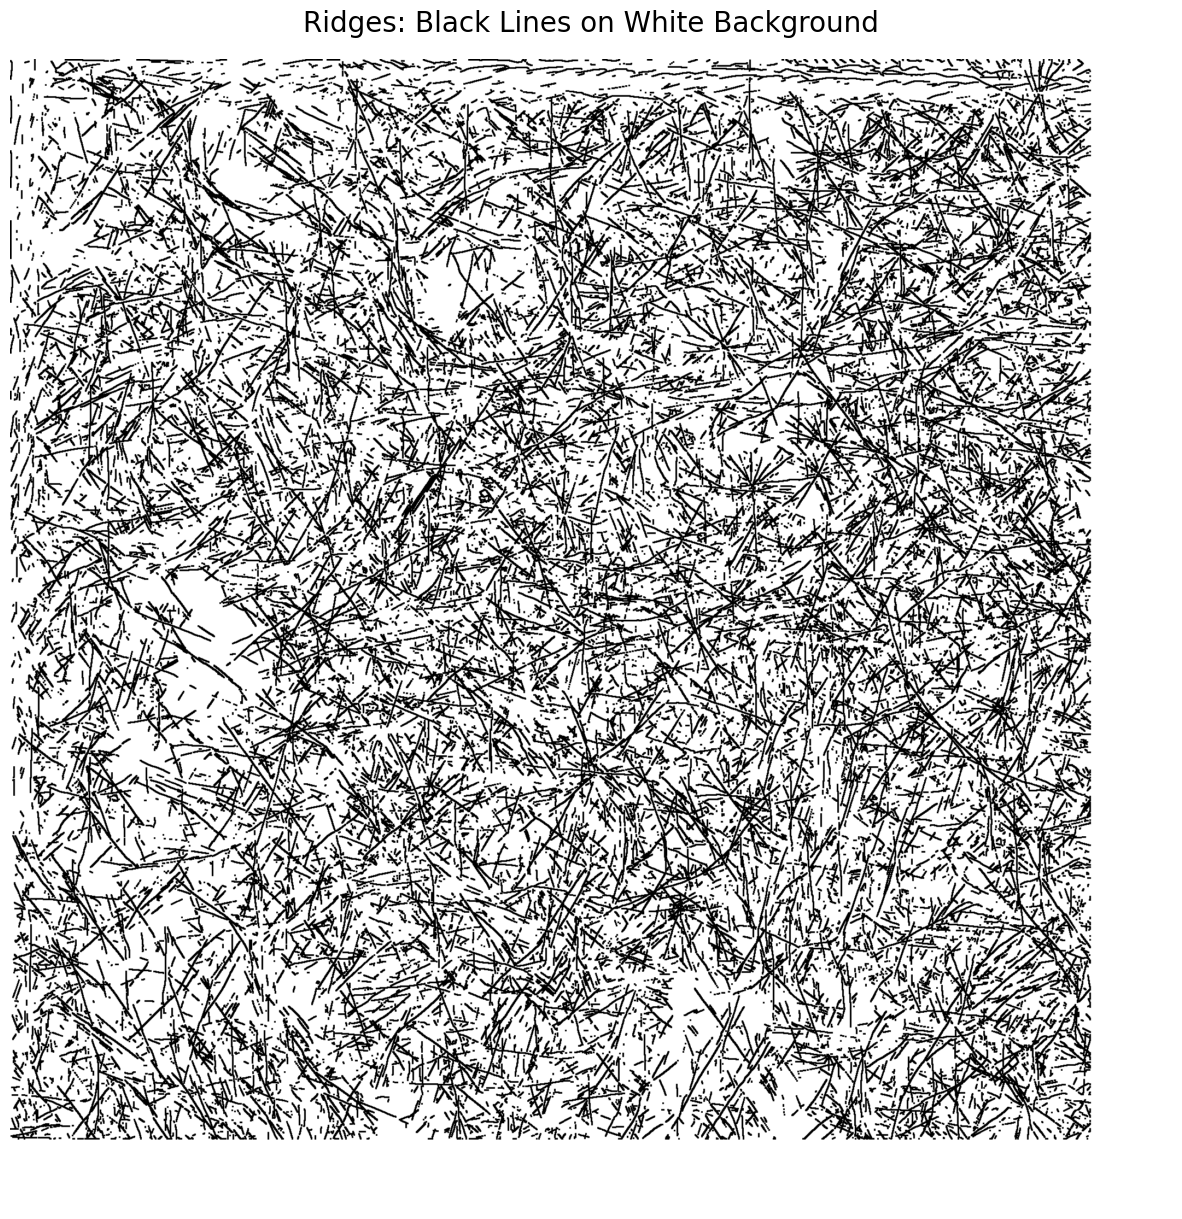

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Linien dicker machen (Dilation)
# Ein 3x3 Kern macht die Linien deutlich kräftiger
kernel = np.ones((3,3), np.uint8)
thick_ridge = cv2.dilate(neg_m.astype(np.float32), kernel, iterations=1)

# 2. Invertieren für weißen Hintergrund mit schwarzen Linien
# Wir nehmen (1 - Map), damit 1 (Linie) zu 0 (Schwarz) wird
inverted_ridges = 1.0 - thick_ridge

# 3. Plotten
plt.figure(figsize=(15, 15), facecolor='white')
plt.imshow(inverted_ridges, cmap='gray', interpolation='bilinear')

plt.title("Ridges: Black Lines on White Background", fontsize=20, pad=20)
plt.axis('off') # Schaltet Achsen und Zahlen aus
plt.show()

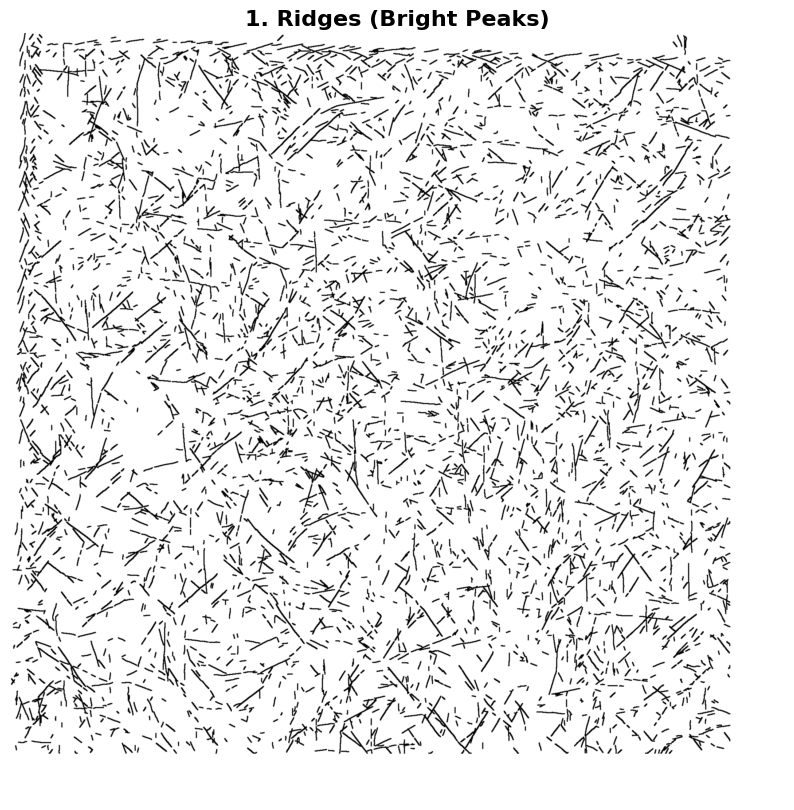

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_small_objects(mask, min_size=5):
    mask_uint8 = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    cleaned_mask = np.zeros_like(mask_uint8)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            cleaned_mask[labels == i] = 1
    return cleaned_mask

def plot_clean_black_white(mask, title, min_size=10):
    # 1. Rauschen entfernen
    clean = remove_small_objects(mask, min_size=min_size)
    # 2. Verdicken (Dilation)
    kernel = np.ones((3,3), np.uint8)
    thick = cv2.dilate(clean.astype(np.float32), kernel, iterations=1)
    # 3. Invertieren (Weißer Hintergrund, schwarze Linien)
    inv = 1.0 - thick
    
    plt.figure(figsize=(10, 10), facecolor='white')
    plt.imshow(inv, cmap='gray', interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

# --- DIE 4 KLASSEN LOGIK (BASIEREND AUF BEST_PHI_DEG) ---
valid_mask = nms_map > 0.15

# 1. Ridges (Helle Rücken) -> Phase ~ 0°
ridge_m = valid_mask & (np.abs(best_phi_deg) <= 45)

# 2. Troughs (Dunkle Gräben) -> Phase ~ 180° / -180°
trough_m = valid_mask & (np.abs(best_phi_deg) > 135)

# 3. Edges: Contacts (Aufwärtsstufen) -> Phase ~ +90°
contact_m = valid_mask & (best_phi_deg > 45) & (best_phi_deg <= 135)

# 4. Edges: Shadows (Abwärtsstufen) -> Phase ~ -90°
shadow_m = valid_mask & (best_phi_deg < -45) & (best_phi_deg >= -135)

# --- VISUALISIERUNG ALLER 4 MAPS ---
plot_clean_black_white(ridge_m, "1. Ridges (Bright Peaks)")
#plot_clean_black_white(trough_m, "2. Troughs (Dark Lines)")
#plot_clean_black_white(contact_m, "3. Edges: Contacts (Up-Steps)")
#plot_clean_black_white(shadow_m, "4. Edges: Shadows (Down-Steps)")